# Predicción de tráfico

---

En este notebook se aborda un mismo problema de regresión desde la perspectiva de varios modelos de aprendizaje automatico supervisado, con el objetivo de predecir el numero de vehiculos por hora que pasen por una conjunto de cruces.

---

Concretamente se implementan:
- **Regresion lineal**
- **Decision Tree**
- **Random Forest**
- **Redes Neuronales**
- **K-NN**
- **Support Vector Machine**
- **Prophet**
- **LightGBM**

---

Para medir el rendimiento de cada modelo se usan metricas de error especificas como (***no todos los modelos usan todas, al no ser necesarias todas***):
- **MAE** (*Mean Absolute Error*)
    - Mide el error medio en unidades reales (vehiculos)
- **MSE** (*Mean Squared Error*)
    - Error al cuadrado, para detectar valores extremos
- **RMSE** (*Root Mean Squared Error*)
    - Mide el error tipico, es similar a MAE pero penaliza mas 'outliers'
- **MAPE** (*Mean Absolute Percentage Error*)
    - Porcentaje de error
- **R²** (*Coeficiente de determinacion*)
    - Proporcion de variacion entre la variable predicha y las variables independientes

---

## Carga de datos

---

Para leer y procesar los datos, al igual que para mejorar la eficiencia en las operaciones se usan las bibliotecas **numpy** y **pandas**

Para graficar los resultados, se usan las biblioteca **matplotlib**

Los distintos dataFrames que se van a usar se guardan en un diccionario, para que en caso de querer iterar sobre ellos se puedan ajustar todos en secuencia

---

In [1]:
from matplotlib import gridspec, pyplot as plt

PALETA_OSCURA_AZUL = {
    'bg':     '#0f1117',
    'panel':  '#1a1d27',
    'accent': '#4f86f7',
    'good':   '#2ecc71',
    'warn':   '#e74c3c',
    'text':   '#e0e0e0',
    'grid':   '#2a2d3a',
}

PALETA_OSCURA_MORADA = {
    'bg':     '#0f1117',
    'panel':  '#1a1d27',
    'accent': '#a259ff',
    'good':   '#2ecc71',
    'warn':   '#e74c3c',
    'text':   '#e0e0e0',
    'grid':   '#2a2d3a',
    'orange': '#f39c12',
}

def aplicar_paleta(PALETA):
    plt.rcParams.update({
        'figure.facecolor':  PALETA['bg'],
        'axes.facecolor':    PALETA['panel'],
        'axes.edgecolor':    PALETA['grid'],
        'axes.labelcolor':   PALETA['text'],
        'xtick.color':       PALETA['text'],
        'ytick.color':       PALETA['text'],
        'text.color':        PALETA['text'],
        'grid.color':        PALETA['grid'],
        'grid.linestyle':    '--',
        'font.family':       'DejaVu Sans',
    })

aplicar_paleta(PALETA_OSCURA_AZUL)

In [2]:
import numpy as np
import pandas as pd

'''
Leer el dataset 'traffic.csv', una vez por cada modelo, para poder procesarlos de forma separada y los guardamos en un diccionario
'''

df_base = pd.read_csv('traffic.csv')
df_others = pd.read_csv('traffic.csv')
df_prophet = pd.read_csv('traffic.csv')
df_lightGBM = pd.read_csv('traffic.csv')

dict_dfs = {
    'df_base': df_base,
    'df_others': df_others,
    'df_prophet': df_prophet,
    'df_lightGBM': df_lightGBM
}

'''
Mostramos el dataset para comprobar que se ha cargado correctamente y saber cuantas entradas tiene
'''

df_base

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


## Comprobar duplicados en el dataset

---

Debido a que pueden aparecer duplicados en el dataset, por cada dataFrame cargado, vamos a eliminar duplicados. **Importante** resaltar que los duplicados para los dataFrames de los modelos **LigthGBM** y **Prophet** se hacen por **separado**, ya que estos modelos requieren un tratado de datos **ligeramente distinto**.

---

In [3]:

'''
Comprobar si el dataset tiene duplicados (y en caso de que los tenga, eliminarlos)
'''

for nombre, df in dict_dfs.items():
    if nombre == 'df_others':
        num_duplicados = df.duplicated().sum()
        print(f"[{nombre.capitalize()}] Numero de duplicados detectados: {num_duplicados}")

        if num_duplicados > 0:
            df.drop_duplicates(inplace = True)
            print(f"    > Duplicados eliminados correctamente. Nuevo tamaño del dataFrame: {len(df)} \n")
        else: print(f"   > No se encontraron duplicados. DataFrame : {len(df)} \n")


[Df_others] Numero de duplicados detectados: 0
   > No se encontraron duplicados. DataFrame : 48120 



## Preprocesado

---

Puesto que los dataFrames contienen una columna '***DateTime***' la cual contiene la informacion temporal concentrada, se pueden añadir columnas especificas para distinguir la **hora**, el **dia de la semana** y el **mes**. De la misma forma, se puede añadir un columna para saber si el dia de la semana cae en **fin de semana**.

Una vez añadidas las nuevas columnas, ahora la columna '***DateTime***' y la columna de '***ID***' sobran, entonces se eliminan de los dataFrames

Al igual que con la comprobacion de los duplicados, esto **no** se realiza para **LightGBM** y **Prophet**, y se deja para despues.

---

In [4]:

'''
Convertir columna DateTime y añadir columnas nuevas
'''

for nombre, df in dict_dfs.items():
    if nombre == 'df_others':
        df['DateTime'] = pd.to_datetime(df['DateTime'])

        df['Hour'] = df['DateTime'].dt.hour
        df['DayOfWeek'] = df['DateTime'].dt.dayofweek
        df['Month'] = df['DateTime'].dt.month

        df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

        df.drop(['DateTime', 'ID'], axis = 1, inplace = True)

'''
Mostrar el dataFrame para ver el resultado
'''

df_others

,Junction,Vehicles,Hour,DayOfWeek,Month,IsWeekend
0,1,15,0,6,11,1
1,1,13,1,6,11,1
2,1,10,2,6,11,1
3,1,7,3,6,11,1
4,1,9,4,6,11,1
...,...,...,...,...,...,...
48115,4,11,19,4,6,0
48116,4,30,20,4,6,0
48117,4,16,21,4,6,0
48118,4,22,22,4,6,0


## Detección y eliminación de elementos outliers

---

Para asegurar que los modelos esta bien entrenados y no trata de ajustarse demasiado a valores extremos, podemos detectar y eliminar '***outliers***'. Existen varios metodos para detectar y eliminar los valores que no se consideran validos, en este caso se usa '**IsolationForest**' con un grado de contaminación de **0.04**

De forma similar, esto **solo** se realiza sobre los **dataFrames necesarios**

---

[Df_knn] Outliers
 1    46195
-1     1925
Name: count, dtype: int64


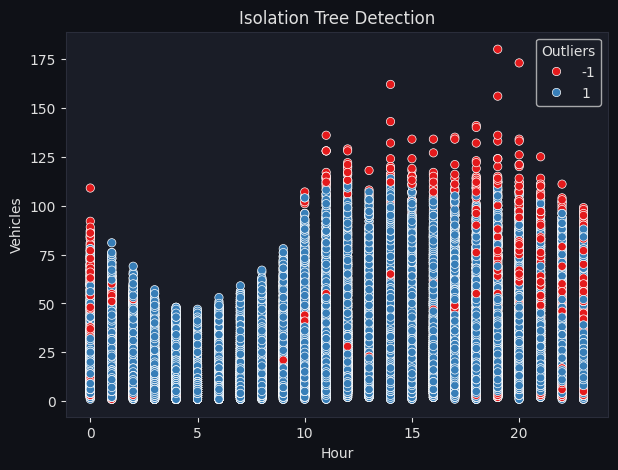

[Df_others] numero de filas tras eliminacion : 46195


,Junction,Vehicles,Hour,DayOfWeek,Month,IsWeekend
1,1,13,1,6,11,1
2,1,10,2,6,11,1
3,1,7,3,6,11,1
4,1,9,4,6,11,1
5,1,6,5,6,11,1
...,...,...,...,...,...,...
48115,4,11,19,4,6,0
48116,4,30,20,4,6,0
48117,4,16,21,4,6,0
48118,4,22,22,4,6,0


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

'''
OTROS METODOS PARA 'OUTLIERS'
--- Usada para la K en el KNN de LOF
    raiz = int(np.round(np.sqrt(df.shape[0])))

    print('Raiz: ' + str(raiz))
    lof = LocalOutlierFactor(n_neighbors=raiz, contamination=0.04)
    y_pred_lof = lof.fit_predict(df)

    df["Outliers"] = y_pred_lof
    print(df["Outliers"].value_counts())
---
    cols = ['Junction', 'Vehicles']

    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1

    df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
---
'''

'''
Calcular el 'IsolationForest' y detectar los 'outliers' para cada dataFrame
'''

iso = IsolationForest(contamination = 0.04, random_state = 1234)
for nombre, df in dict_dfs.items():
    if nombre == 'df_others':
        y_pred_iso = iso.fit_predict(df)
        df["Outliers"] = y_pred_iso

'''
Mostrar los 'outliers' detectados en uno de los dataFrames y los grafica
'''

print(f"[{'df_knn'.capitalize()}] {df_others['Outliers'].value_counts()}")

plt.figure(figsize = (7, 5))
sns.scatterplot(x = "Hour", y = "Vehicles", data = df_others, hue = "Outliers", palette = 'Set1')
plt.title("Isolation Tree Detection")
plt.show()

'''
Eliminar los 'outliers' de los dataFrames y mostrar un dataFrame de ejemplo
'''

for nombre, df in dict_dfs.items():
    if nombre == 'df_others':
        outliers = df.loc[df['Outliers'] == -1].index
        df.drop(outliers, inplace = True)
        df.drop(['Outliers'], axis =1, inplace = True)

print(f"[{'df_others'.capitalize()}] numero de filas tras eliminacion : {len(df_others)}")
df_others


## Aplicación de OneHotEncoding

---

En el estado actual, los dataFrames tienes una columna 'Junction' que representa en que cruce se midieron la cantidad de vehiculos. Esta columna se tiene que expandir en tantas columnas como posibles valores contiene. Para ello, se aplica 'one-hot encoding', la cual crea tantas columnas como sean necesarias y darles valor 0 o 1.

---

In [6]:
from sklearn.preprocessing import OneHotEncoder

'''
Crear el codificador, ajustar y transformar los dataFrames
    - Se elimina la columna 'Junction' 
'''

oneHotEncoder = OneHotEncoder(drop = 'first')
for nombre, df in dict_dfs.items():
    if nombre == 'df_others':
        oneHotEncoderFit = oneHotEncoder.fit(df['Junction'].values.reshape(-1, 1))
        junction_encoded = oneHotEncoderFit.transform(df['Junction'].values.reshape(-1, 1)).toarray()

        ini = df['Junction'].min()
        fin = df['Junction'].max()

        nuevas_Junctions = []
        for idx in range(ini + 1, fin + 1): nuevas_Junctions.append(f'Junction_{idx}')

        df[nuevas_Junctions] = junction_encoded
        df.drop(['Junction'], axis = 1, inplace = True)

'''
Mostrar un dataFrame de ejemplo
'''

df_others

,Vehicles,Hour,DayOfWeek,Month,IsWeekend,Junction_2,Junction_3,Junction_4
1,13,1,6,11,1,0.0,0.0,0.0
2,10,2,6,11,1,0.0,0.0,0.0
3,7,3,6,11,1,0.0,0.0,0.0
4,9,4,6,11,1,0.0,0.0,0.0
5,6,5,6,11,1,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
48115,11,19,4,6,0,0.0,0.0,1.0
48116,30,20,4,6,0,0.0,0.0,1.0
48117,16,21,4,6,0,0.0,0.0,1.0
48118,22,22,4,6,0,0.0,0.0,1.0


## Gráficas

---

Para saber un poco sobre los datos actuales y estadisticas basicas del los dataFrames (que hasta este punto son iguales salvo los usados para LightGBM y Prophet, los cuales estan sin preprocesar), se pueden graficar el **trafico medio por hora del dia** y el **trafico medio por cruce**, en este caso se emplean dos visualizaciones, grafico por lineas y un digrama de barras respectivamente.

---

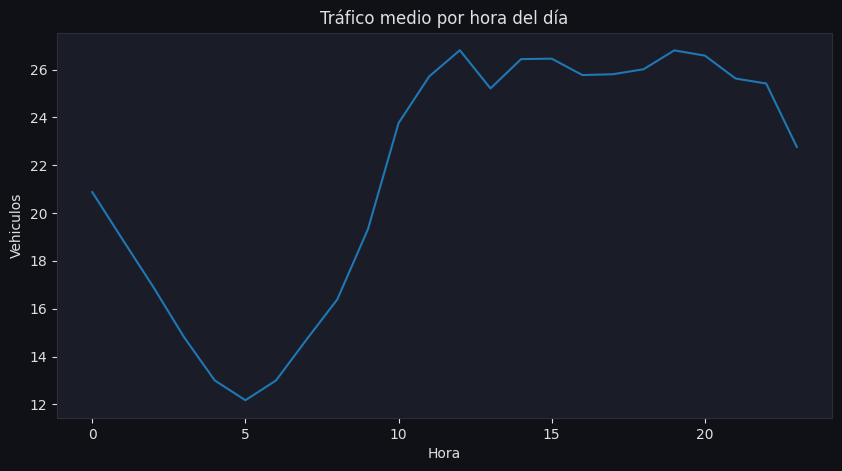

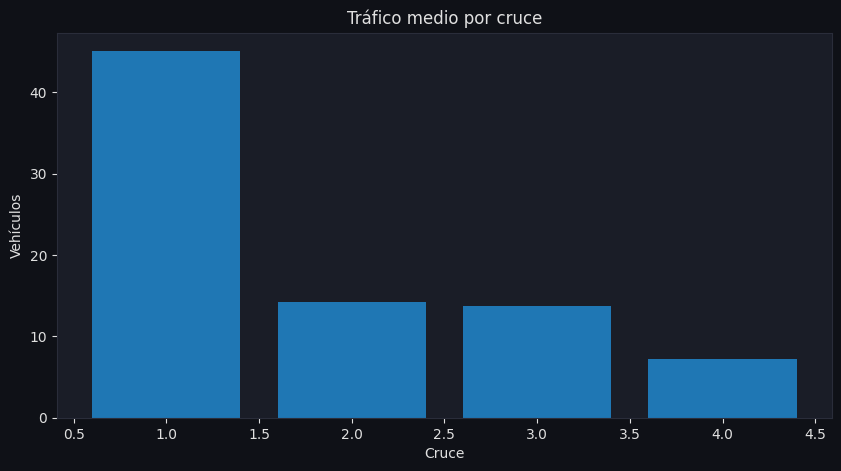

In [7]:

'''
Trafico medio por hora de un dataFrame tratado
'''

trafico_por_hora = df_others.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize = (10, 5))
plt.plot(trafico_por_hora.index, trafico_por_hora.values)

plt.title('Tráfico medio por hora del día')
plt.xlabel('Hora')
plt.ylabel('Vehiculos')

'''
Trafico medio por hora del dataset sin tratar
'''

trafico_por_cruce = df_base.groupby('Junction')['Vehicles'].mean()

plt.figure(figsize = (10, 5))
plt.bar(trafico_por_cruce.index, trafico_por_cruce.values)

plt.title('Tráfico medio por cruce')
plt.xlabel('Cruce')
plt.ylabel('Vehículos')

plt.show()


## Separar features-target y entrenamiento-test

---

Para entrenar los modelos hay que distinguir entre la variable a predecir '***Vehicles***' y el resto de variables, para ello se guarda en '***X***' el conjunto de datos distinto de la variable a predecir, y en la variable '***Y***' la variable que se quiere predecir.

Respecto a los datos de entrenamiento y de test, al no tener varios datasets distintos para poder entrenar los modelos sobre uno de ellos y usar los otros para evaluar las soluciones generadas, se separa el dataset en **2 conjuntos distintos**, uno para **entrenamiento** y otro para **validación**

---

In [8]:
from sklearn.model_selection import train_test_split

'''
Asignación de las columnas de variables y columna de objetivo (cualquier dataFrame tratado es valido para ello)
'''

X = df_others.drop(['Vehicles'], axis = 1)
Y = df_others['Vehicles']

'''
Particion de los datos para entrenar y validar
    - Se entrena con un 80% del dataset:
        - x_train: el 80% de las filas de 'X', para entrenar el modelo
        - y_train: el 80% de los valores de Vehicles, para entrenar
    - Se valida con un 20% del dataset:
        - x_test: el 20% de las filas de 'X', para validar el modelo
        -y_test: el 20% de los valores de Vehicles, para validar
'''

x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size = 0.8, random_state = 1234)

'''
Mostrar la cantidad de filas usadas para entrenar y validar
'''

print(f"Numero de filas para entrenar: {len(x_train)}")
print(f"Numero de filas para validar: {len(x_test)}")

Numero de filas para entrenar: 36956
Numero de filas para validar: 9239


## Comprobar si hay valores nulos o no válidos

---

Hasta este punto, los dataFrames pueden tener valores nulos o no validos. Para contabilizar la cantidad de valores no validos **pandas** contiene una funcion '***isna()***' que cuantifica la cantida de celdas con valores '***NaN***', '***None***' o '***numpy.NaN***'

---

In [9]:
'''
Mostrar la cantidad de valores no validos
'''

x_train.isna().sum()


Hour          0
DayOfWeek     0
Month         0
IsWeekend     0
Junction_2    0
Junction_3    0
Junction_4    0
dtype: int64

## Prediccion del tráfico con Regresión Lineal

### Crear y entrenar el modelo Regresión Lineal

In [10]:
from sklearn import linear_model

'''
Calculo de la regresion linea
'''

regr = linear_model.LinearRegression()
regr_fit = regr.fit(x_train, y_train)
y_pred = regr_fit.predict(x_test)

pd.DataFrame({"Predicciones": y_pred, "Valores reales": y_test})

,Predicciones,Valores reales
15123,9.128816,6
17880,10.788304,9
39889,11.095938,13
32258,10.579271,9
35426,8.913770,5
...,...,...
45347,8.839615,11
47357,4.496931,6
5592,38.169580,41
26605,18.402434,25


### Calcular métricas

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

'''
Mostrar las metricas calculadas
'''

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'R²: {r2_score(y_test, y_pred)}')


MAE: 8.37828887635091
MSE: 141.25725838133116
R²: 0.5927492957341438


### Grafica

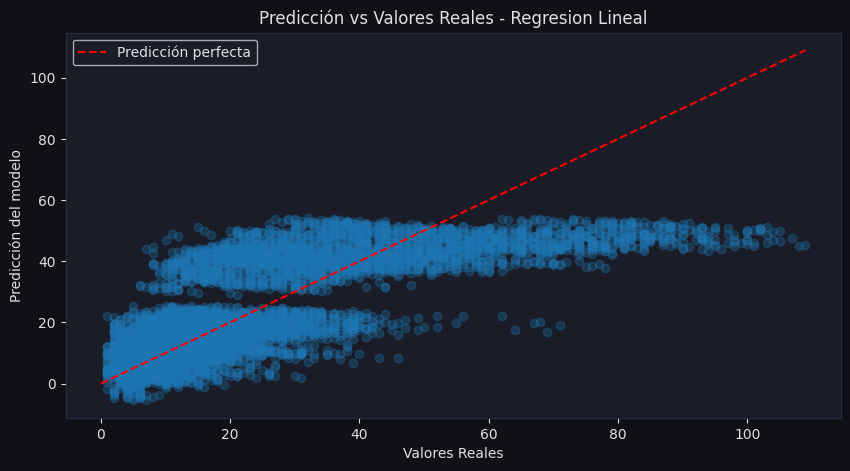

In [12]:

'''
Grafica de la Prediccion vs Valores Reales
'''

max_val = max(y_test.max(), y_pred.max())

plt.figure(figsize = (10, 5))
plt.scatter(y_test, y_pred, alpha = 0.3)
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label = 'Predicción perfecta')

plt.title('Predicción vs Valores Reales - Regresion Lineal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()

plt.show()

## Prediccion del tráfico con Random Forest

### Crear y entrenar el modelo Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor

'''
Calculo del random Forest
'''

regr = RandomForestRegressor(n_estimators = 100, random_state = 1234)
regr_fit = regr.fit(x_train, y_train)
y_pred = regr_fit.predict(x_test)

pd.DataFrame({"Predicciones": y_pred, "Valores reales": y_test})

,Predicciones,Valores reales
15123,8.082491,6
17880,21.417966,9
39889,9.729051,13
32258,7.786717,9
35426,5.641143,5
...,...,...
45347,10.433929,11
47357,4.360829,6
5592,49.478206,41
26605,19.049814,25


### Calcular métricas

In [14]:
'''
Mostrar las metricas calculadas
'''

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'R²: {r2_score(y_test, y_pred)}')

MAE: 7.461481271654766
MSE: 115.86886472794878
R²: 0.6659451181223068


### Grafica

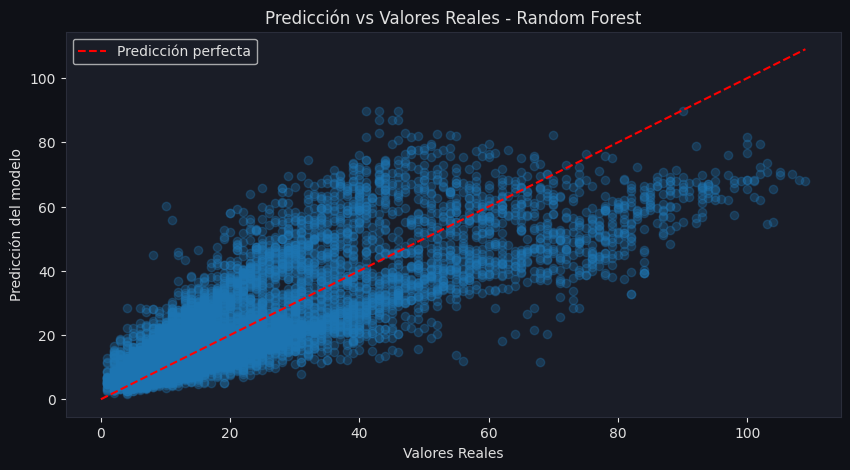

In [15]:
'''
Grafica de la Prediccion vs Valores Reales
'''

max_val = max(y_test.max(), y_pred.max())

plt.figure(figsize = (10, 5))
plt.scatter(y_test, y_pred, alpha = 0.3)
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label = 'Predicción perfecta')

plt.title('Predicción vs Valores Reales - Random Forest')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()

plt.show()

## Predicción de tráfico con KNN

### Método del codo para obtener la K óptima

---

Para saber el mejor valor de K para '**K-NN**' se emplea el metodo del codo, basado en generar varias versiones del modelo con distintos valores de k y elegir aquel que tenga menor ratio de error

---

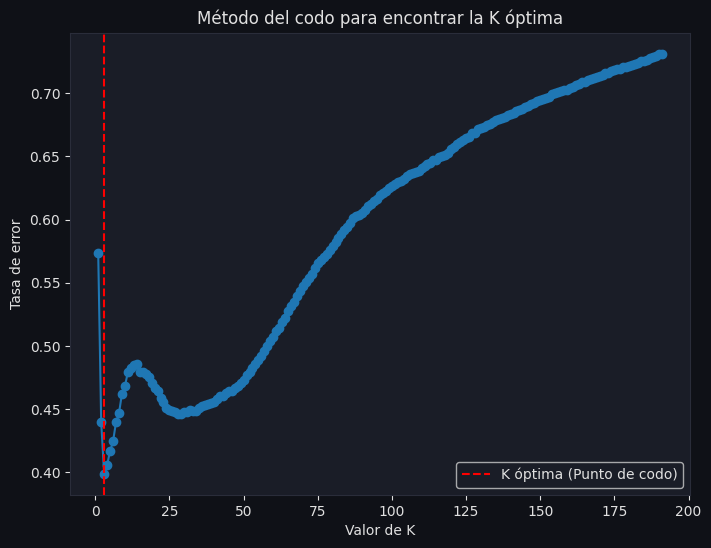

K elegida: 3


In [16]:
from sklearn.neighbors import KNeighborsRegressor as KNN

'''
Usar el metodo del codo
'''

raiz = int(np.round(np.sqrt(x_train.shape[0]))) # Una K por defecto

k_optima = raiz
k_values = range(1, raiz)

error_rates = []
min_error_rate = 1.0

for k in k_values:
    knn = KNN(n_neighbors = k)
    knn.fit(x_train, y_train)

    y_pred_knn = knn.predict(x_test)
    error_rate = 1 - knn.score(x_test, y_test)
    error_rates.append(error_rate)

    if error_rate < min_error_rate: # Nos quedamos con la K que minimice el error
        min_error_rate = error_rate
        k_optima = k

'''
Graficar el resultado
'''

plt.figure(figsize = (8, 6))
plt.plot(k_values, error_rates, marker = 'o')
plt.axvline(x = 3, linestyle = '--', color = 'red', label = "K óptima (Punto de codo)")

plt.xlabel('Valor de K')
plt.ylabel('Tasa de error')
plt.title('Método del codo para encontrar la K óptima')

plt.legend()
plt.show()

print('K elegida: ' + str(k_optima))

### Crear y entrenar el modelo KNN

In [17]:
'''
Entrenar el modelo con la 'k' optima calculada
'''

knn = KNN(n_neighbors = k_optima)

knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

pd.DataFrame({"Predicciones": y_pred_knn, "Valores reales": y_test})

,Predicciones,Valores reales
15123,9.000000,6
17880,23.333333,9
39889,7.333333,13
32258,9.333333,9
35426,5.666667,5
...,...,...
45347,10.666667,11
47357,4.000000,6
5592,51.666667,41
26605,21.333333,25


### Calcular métricas

In [18]:
'''
Mostrar las metricas de rendimiento
'''

print(f'MAE: {mean_absolute_error(y_test, y_pred_knn)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_knn)}')
print(f'R²: {r2_score(y_test, y_pred_knn)}')

MAE: 8.014034707940974
MSE: 138.39043427018316
R²: 0.6010144719923407


### Grafica

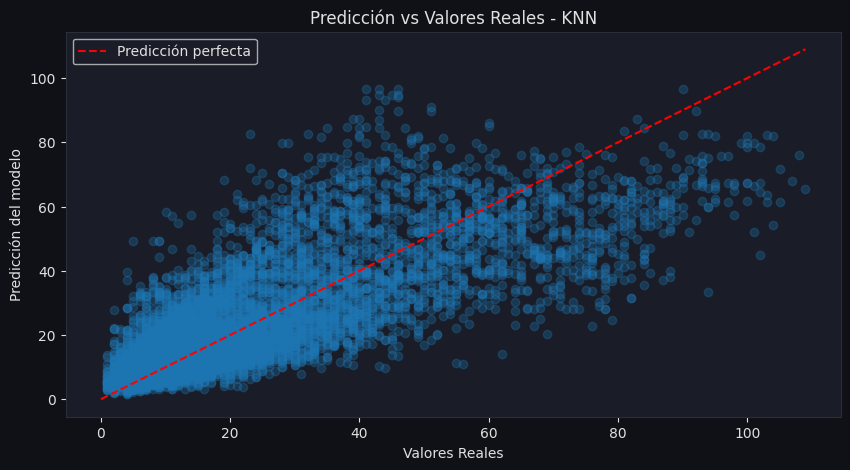

In [19]:
'''
Grafica de la Prediccion vs Valores Reales
'''

max_val = max(y_test.max(), y_pred_knn.max())

plt.figure(figsize = (10, 5))
plt.scatter(y_test, y_pred_knn, alpha = 0.3)
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label = 'Predicción perfecta')

plt.title('Predicción vs Valores Reales - KNN')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()

plt.show()

## Predicción de tráfico con Red Neuronal

### Crear y entrenar el modelo Red Neuronal

In [20]:
from sklearn.neural_network import MLPRegressor

'''
Creacion de la red con un perceptron multicapa
'''

clf = MLPRegressor(random_state = 1, max_iter = 1000, hidden_layer_sizes = (64, 32))
clf.fit(x_train, y_train)
y_pred_nn = clf.predict(x_test)

pd.DataFrame({"Predicciones": y_pred_nn, "Valores reales": y_test})

,Predicciones,Valores reales
15123,9.243077,6
17880,20.343896,9
39889,9.925627,13
32258,8.981063,9
35426,7.363462,5
...,...,...
45347,8.791569,11
47357,3.147066,6
5592,49.212140,41
26605,19.316504,25


### Calcular métricas

In [21]:
'''
Mostrar las metricas
'''

print(f'MAE: {mean_absolute_error(y_test, y_pred_nn)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_nn)}')
print(f'R²: {r2_score(y_test, y_pred_nn)}')

MAE: 6.929180853660626
MSE: 95.969288291246
R²: 0.7233164462317762


### Grafica

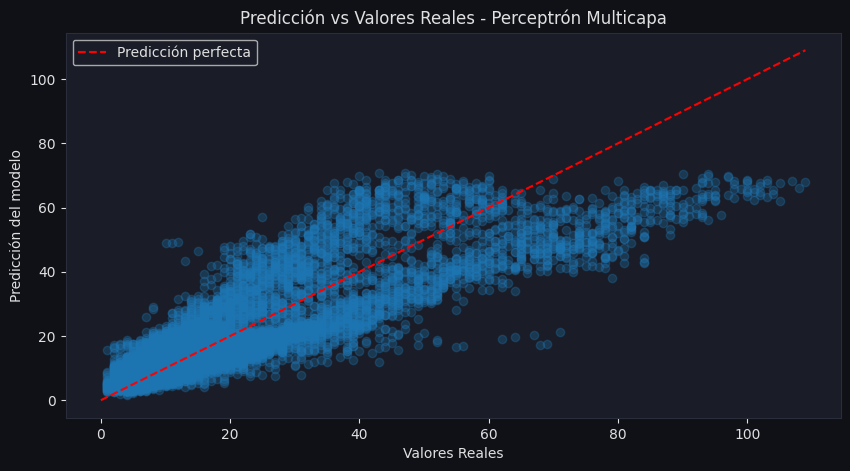

In [22]:
'''
Mostrar la Prediccion vs Valores Reales
'''

max_val = max(y_test.max(), y_pred_nn.max())

plt.figure(figsize = (10, 5))
plt.scatter(y_test, y_pred_nn, alpha = 0.3)
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label = 'Predicción perfecta')

plt.title('Predicción vs Valores Reales - Perceptrón Multicapa')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()

plt.show()

## Predicción de tráfico con Support Vector Machine

### Crear y entrenar el modelo SVM

In [23]:
from sklearn.svm import SVR

'''
Entrenamiento del modelo con nucleo 'poly'
'''

svm = SVR(kernel = 'poly')
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

pd.DataFrame({"Predicciones": y_pred_svm, "Valores reales": y_test})

,Predicciones,Valores reales
15123,11.696548,6
17880,17.729781,9
39889,17.390271,13
32258,17.802972,9
35426,15.182811,5
...,...,...
45347,12.711361,11
47357,16.074247,6
5592,18.476167,41
26605,14.752596,25


### Calcular métricas

In [24]:
'''
Mostrar metricas
'''

print(f'MAE: {mean_absolute_error(y_test, y_pred_svm)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_svm)}')
print(f'R²: {r2_score(y_test, y_pred_svm)}')

MAE: 9.551797452357889
MSE: 217.63113252812698
R²: 0.3725601572062709


### Grafica

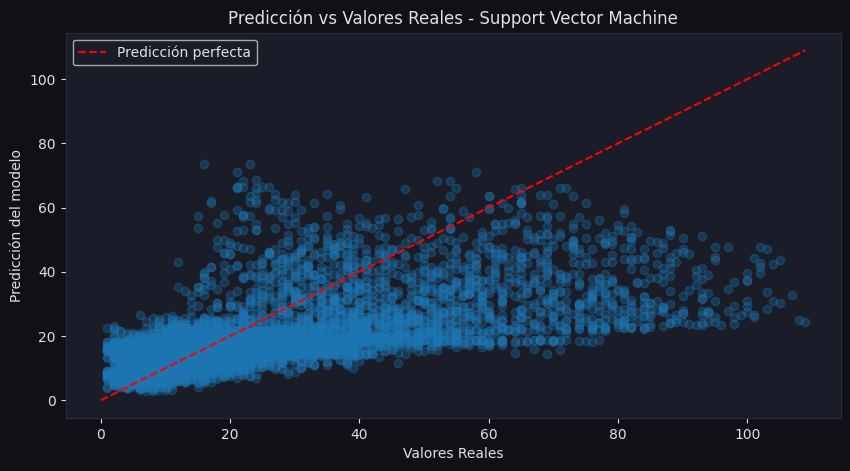

In [25]:
'''
Grafica de Prediccion vs Valores Reales
'''

max_val = max(y_test.max(), y_pred_svm.max())

plt.figure(figsize = (10, 5))
plt.scatter(y_test, y_pred_svm, alpha = 0.3)
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label = 'Predicción perfecta')

plt.title('Predicción vs Valores Reales - Support Vector Machine')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()

plt.show()